# Nutrient Profiles Analysis: Food Group Classification

The objective of this paper is to extract meaningful insights from the Nutrient profiles dataset using machine learning techniques.

To achieve this, we employ Exploratory Data Analysis (EDA) to reveal preliminary inquiries.

# Exploratory Data Analysis

## Dataset Overview

Public Food Key: An alphanumeric ID for each food

Classification: A numeric category to classify each food

Derivation: A category to denote the source of a food's nutrient data.

Food Name: Name of the food.

---

Nutrients: According to xxx, at least k of n nutrients data are filled for each row.

## Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%pip install pandas openpyxl

plt.style.use('bmh')

Note: you may need to restart the kernel to use updated packages.


## Load Dataset

In [ ]:
df = pd.read_excel('AUSNUT 2023 - Food nutrient profiles.xlsx', sheet_name="All solids & liquids per 100 g", skiprows=2)
df.head()

,Public Food Key,Classification,Derivation,Food Name,"Energy with dietary fibre, equated \n(kJ)","Energy, without dietary fibre, equated \n(kJ)",Moisture (water) \n(g),Protein \n(g),Nitrogen \n(g),"Fat, total \n(g)",...,Leucine \n(mg),Lysine \n(mg),Methionine \n(mg),Phenylalanine \n(mg),Proline \n(mg),Serine \n(mg),Threonine \n(mg),Tyrosine \n(mg),Tryptophan \n(mg),Valine \n(mg)
0,F002258,31302,Borrowed,"Cardamom seed, dried, ground",1236,1012,8.3,10.8,1.72,6.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155,NaN
1,F002963,31302,Borrowed,"Cinnamon, dried, ground",1004,579,10.6,4.0,0.64,1.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49,NaN
2,F002893,31302,Borrowed,"Chilli (chili), dried, ground",1224,950,10.8,12.3,2.00,14.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64,NaN
3,F002970,31302,Borrowed,"Cloves, dried, ground",1389,1118,9.9,6.0,0.96,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30,NaN
4,F003190,31302,Borrowed,"Coriander seed, dried, ground",1344,1009,8.9,12.4,1.98,17.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178,NaN


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1588 entries, 0 to 1587
Columns: 272 entries, Public Food Key to Valine 
(mg)
dtypes: float64(249), int64(20), str(3)
memory usage: 3.3 MB


## Column Name Formatting

In [63]:
df.columns = df.columns.str.replace('\n', '', regex=False).str.strip()

## 2 Digit Classification

In [64]:
df = df.copy()
df['class_2digit'] = df['Classification'].astype(str).str[:2].astype(int)

# Preliminary

## Drop

In [65]:
df = df.drop(columns=["Public Food Key", "Derivation", "Food Name", "Classification"])
df = df.drop_duplicates()

## Type Check

In [66]:
print(df.dtypes)

Energy with dietary fibre, equated (kJ)          int64
Energy, without dietary fibre, equated (kJ)      int64
Moisture (water) (g)                           float64
Protein (g)                                    float64
Nitrogen (g)                                   float64
                                                ...   
Threonine (mg)                                 float64
Tyrosine (mg)                                  float64
Tryptophan (mg)                                  int64
Valine (mg)                                    float64
class_2digit                                     int64
Length: 269, dtype: object


## Null Check

In [67]:
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_percent': df.isnull().sum() / len(df) * 100
})
print(null_summary)

                                             null_count  null_percent
Energy with dietary fibre, equated (kJ)               0      0.000000
Energy, without dietary fibre, equated (kJ)           0      0.000000
Moisture (water) (g)                                  0      0.000000
Protein (g)                                           0      0.000000
Nitrogen (g)                                          0      0.000000
...                                                 ...           ...
Threonine (mg)                                     1387     87.729285
Tyrosine (mg)                                      1387     87.729285
Tryptophan (mg)                                       0      0.000000
Valine (mg)                                        1387     87.729285
class_2digit                                          0      0.000000

[269 rows x 2 columns]


# EDA

In [68]:
import matplotlib.pyplot as plt
import math

def plot_numeric_grid(df, target='classification', ncols=4, figsize_w=20):
    num_cols = df.select_dtypes(include='number').columns.tolist()
    num_cols = [col for col in num_cols if col != target]  # exclude target

    nrows = math.ceil(len(num_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_w, nrows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        ax = axes[i]
        data = df[col].dropna()

        # Histogram + KDE
        data.hist(ax=ax, bins=30, color='steelblue', alpha=0.7,
                  density=True, edgecolor='white')
        data.plot.kde(ax=ax, color='crimson', linewidth=1.5)

        # Summary stats
        ax.set_title(
            f"{col}\n"
            f"n={len(data):,}  missing={df[col].isna().sum():,}  "
            f"mean={data.mean():.2f}  skew={data.skew():.2f}",
            fontsize=7
        )
        ax.tick_params(labelsize=6)
        ax.set_ylabel("")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Feature Distributions (excl. target)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("numeric_distributions.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_numeric_grid(df, target='classification')

ValueError: `dataset` input should have multiple elements.

Error in callback <function flush_figures at 0x15dbfccc0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [69]:
df.columns.tolist()

['Energy with dietary fibre, equated (kJ)',
 'Energy, without dietary fibre, equated (kJ)',
 'Moisture (water) (g)',
 'Protein (g)',
 'Nitrogen (g)',
 'Fat, total (g)',
 'Ash (g)',
 'Total dietary fibre (g)',
 'Alcohol (g)',
 'Fructose (g)',
 'Glucose (g)',
 'Sucrose(g)',
 'Maltose (g)',
 'Lactose (g)',
 'Galactose (g)',
 'Total sugars (g)',
 'Added sugars (g)',
 'Free sugars (g)',
 'Starch (g)',
 'Dextrin (g)',
 'Glycerol (g)',
 'Glycogen (g)',
 'Inulin (g)',
 'Erythritol (g)',
 'Maltitol (g)',
 'Mannitol (g)',
 'Xylitol (g)',
 'Maltodextrin (g)',
 'Oligosaccharides  (g)',
 'Polydextrose (g)',
 'Raffinose (g)',
 'Stachyose (g)',
 'Sorbitol (g)',
 'Resistant starch (g)',
 'Available carbohydrate, without sugar alcohols (g)',
 'Available carbohydrate, with sugar alcohols (g)',
 'Acetic acid (g)',
 'Citric acid (g)',
 'Fumaric acid (g)',
 'Lactic acid (g)',
 'Malic acid (g)',
 'Oxalic acid (g)',
 'Propionic acid (g)',
 'Quinic acid (g)',
 'Shikimic acid (g)',
 'Succinic acid (g)',
 'Tart

In [75]:
cols_of_interest = ['Moisture (water) (g)', 'Alcohol (g)', 'Sodium (Na) (mg)',
                    'Total dietary fibre (g)', 'Cholesterol (mg)', 'Caffeine (mg)']

for col in cols_of_interest:
    print(f"{col.strip()}: skew={df[col].skew():.2f}, zeros={( df[col]==0).sum()}, missing={df[col].isna().sum()}")

Moisture (water) (g): skew=-0.59, zeros=27, missing=0
Alcohol (g): skew=12.61, zeros=1547, missing=0
Sodium (Na) (mg): skew=17.60, zeros=85, missing=0
Total dietary fibre (g): skew=5.46, zeros=649, missing=0
Cholesterol (mg): skew=7.15, zeros=873, missing=0
Caffeine (mg): skew=37.98, zeros=1513, missing=0


In [76]:
import numpy as np
import matplotlib.pyplot as plt

def plot_before_after(df, cols, figsize=(12, 3)):
    """Show raw vs log-transformed side by side for selected features."""
    fig, axes = plt.subplots(len(cols), 2, figsize=(figsize[0], len(cols) * figsize[1]))
    
    for i, col in enumerate(cols):
        data = df[col].dropna()
        
        # Raw
        ax_raw = axes[i, 0] if len(cols) > 1 else axes[0]
        data.hist(ax=ax_raw, bins=30, color='steelblue', alpha=0.7,
                  density=True, edgecolor='white')
        data.plot.kde(ax=ax_raw, color='crimson', linewidth=1.5)
        ax_raw.set_title(f"{col} — raw  (skew: {data.skew():.2f})", fontsize=9)

        # Log transformed
        ax_log = axes[i, 1] if len(cols) > 1 else axes[1]
        log_data = np.log1p(data)
        log_data.hist(ax=ax_log, bins=30, color='steelblue', alpha=0.7,
                      density=True, edgecolor='white')
        log_data.plot.kde(ax=ax_log, color='crimson', linewidth=1.5)
        ax_log.set_title(f"{col} — log transformed  (skew: {log_data.skew():.2f})", fontsize=9)

    plt.suptitle("Log Transformation Justification", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig("log_transform_justification.png", dpi=150, bbox_inches='tight')
    plt.show()

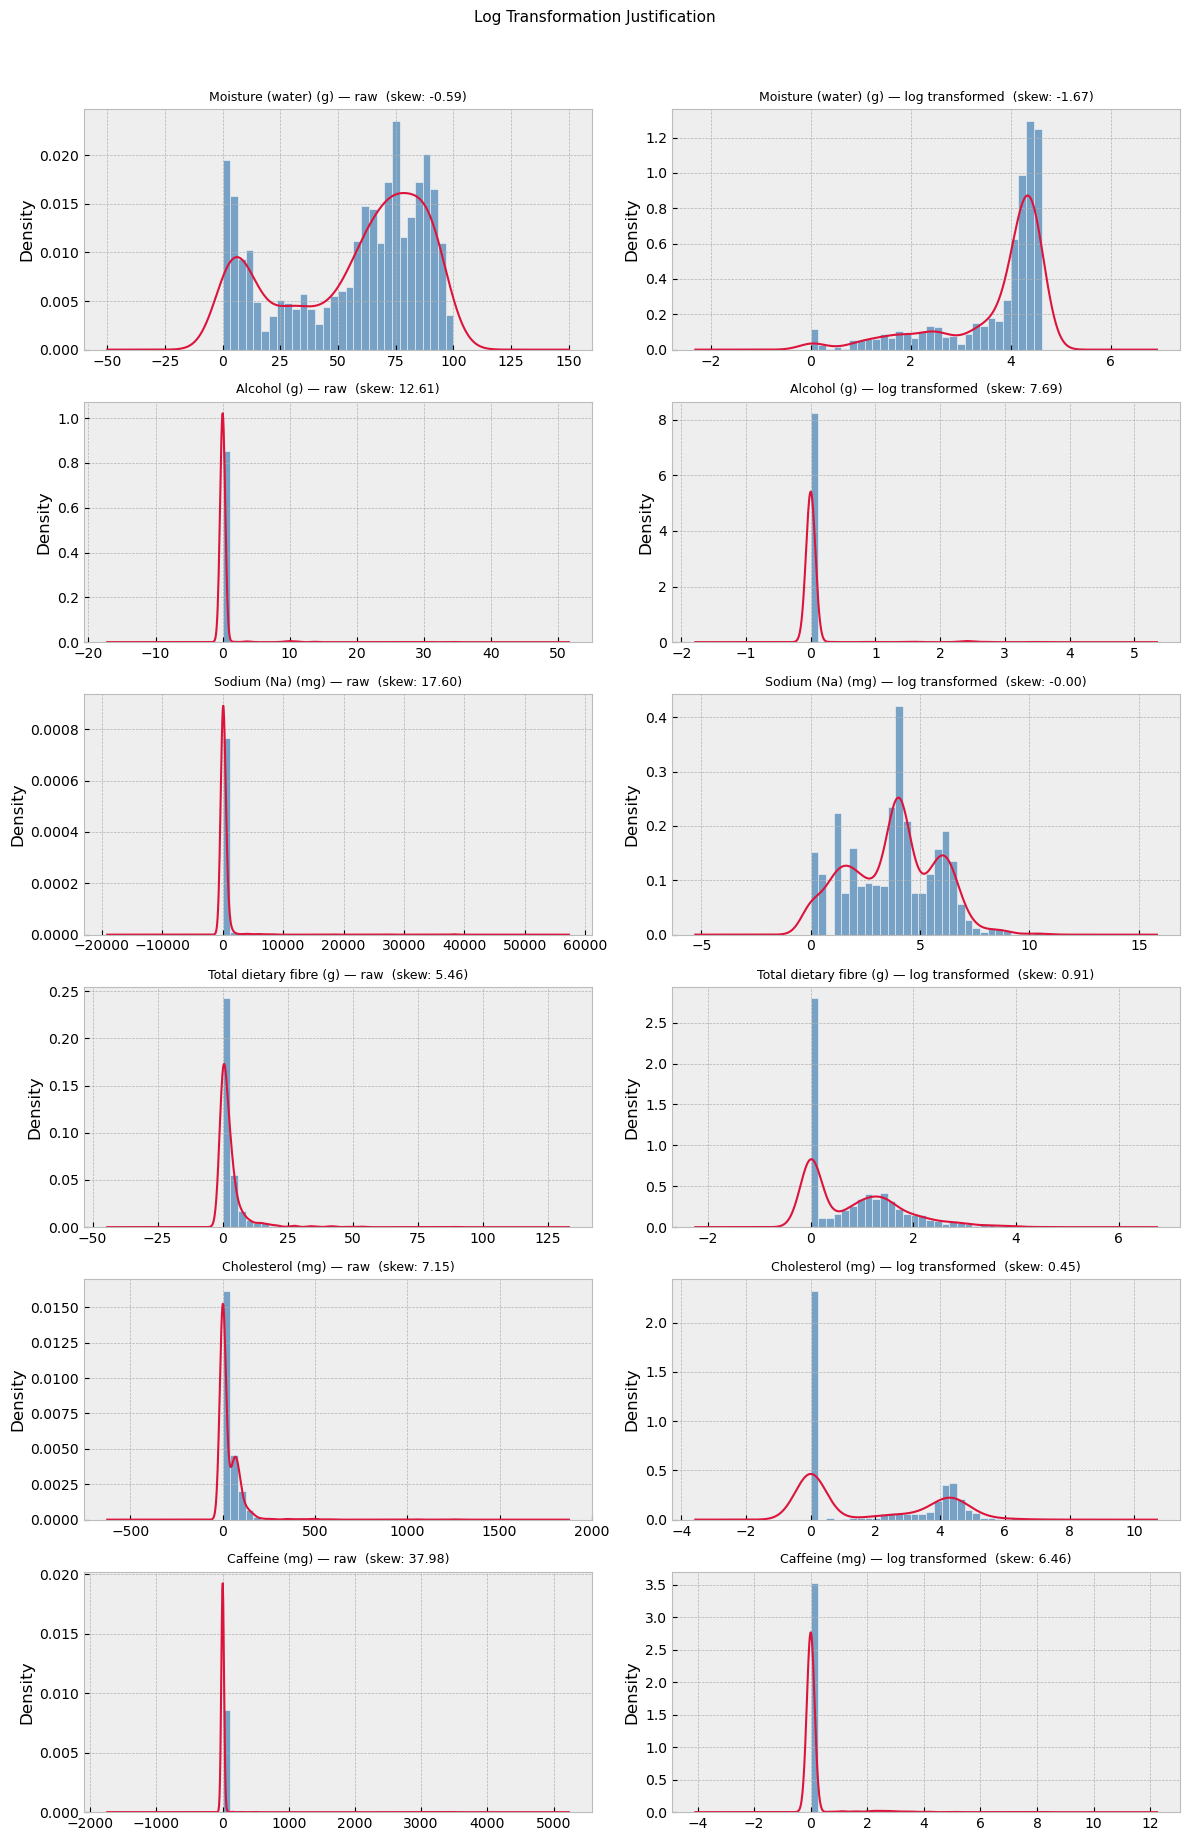

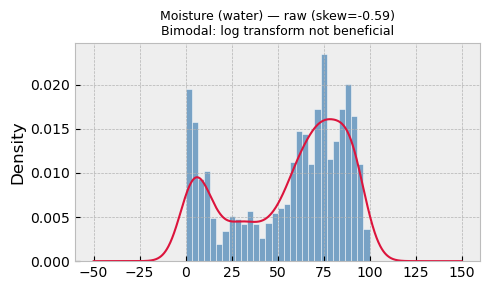

In [77]:
plot_before_after(df, cols=[
    'Moisture (water) (g)',
    'Alcohol (g)',
    'Sodium (Na) (mg)',
    'Total dietary fibre (g)',
    'Cholesterol (mg)',
    'Caffeine (mg)'
])

# Show moisture raw only — transformation not beneficial here
fig, ax = plt.subplots(figsize=(5, 3))
df['Moisture (water) (g)'].dropna().hist(
    ax=ax, bins=30, color='steelblue', alpha=0.7, density=True, edgecolor='white')
df['Moisture (water) (g)'].dropna().plot.kde(ax=ax, color='crimson', linewidth=1.5)
ax.set_title('Moisture (water) — raw (skew=-0.59)\nBimodal: log transform not beneficial', fontsize=9)
plt.tight_layout()
plt.savefig('moisture_raw.png', dpi=150, bbox_inches='tight')

## Moisture Bimodal Split by Food Group

In [78]:
df.groupby('class_2digit')['Moisture (water) (g)'].median().sort_values()

class_2digit
14     0.00
26     2.30
22     4.75
21     5.10
28     5.50
30     8.40
31     8.80
25    11.20
27    17.20
13    24.10
12    25.20
18    64.10
19    65.35
23    71.40
15    72.30
17    75.30
33    76.15
20    81.00
16    84.20
32    87.50
29    87.90
24    88.30
11    90.25
Name: Moisture (water) (g), dtype: float64

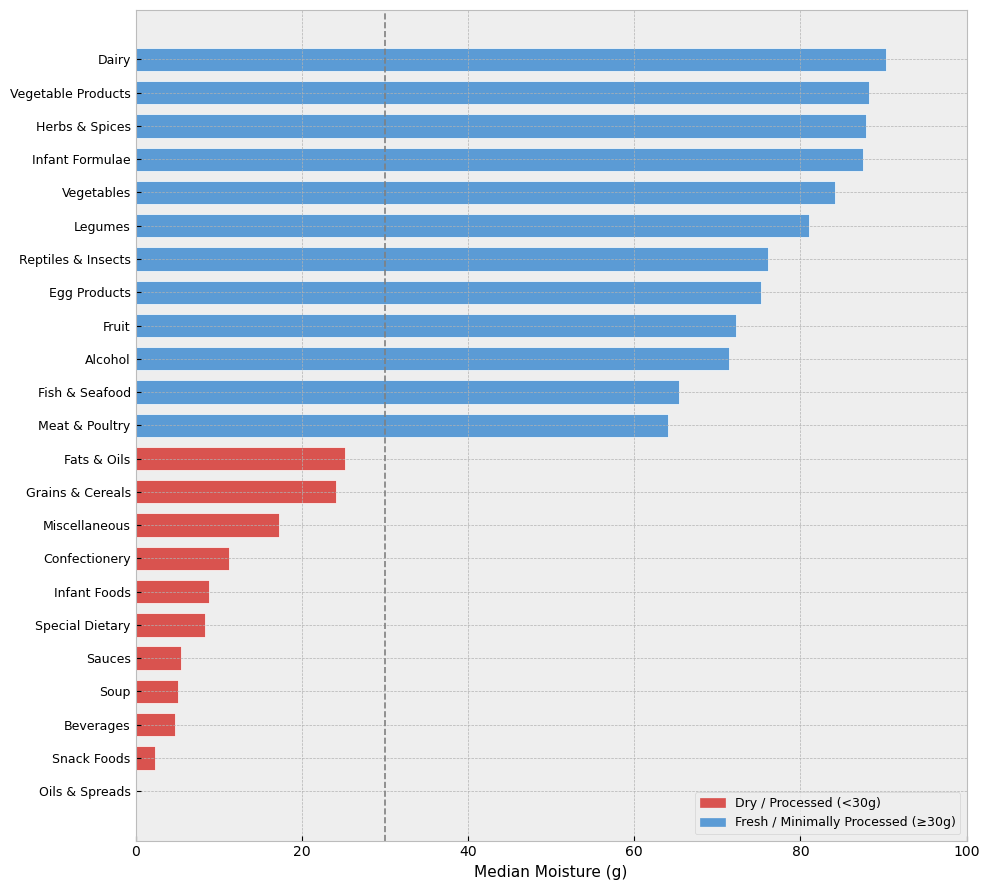

In [79]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Median moisture per class
moisture_medians = {
    14: 0.00, 26: 2.30, 22: 4.75, 21: 5.10, 28: 5.50,
    30: 8.40, 31: 8.80, 25: 11.20, 27: 17.20, 13: 24.10,
    12: 25.20, 18: 64.10, 19: 65.35, 23: 71.40, 15: 72.30,
    17: 75.30, 33: 76.15, 20: 81.00, 16: 84.20, 32: 87.50,
    29: 87.90, 24: 88.30, 11: 90.25
}

# AUSNUT class labels — update any you know
class_labels = {
    11: 'Dairy', 12: 'Fats & Oils', 13: 'Grains & Cereals',
    14: 'Oils & Spreads', 15: 'Fruit', 16: 'Vegetables',
    17: 'Egg Products', 18: 'Meat & Poultry', 19: 'Fish & Seafood',
    20: 'Legumes', 21: 'Soup', 22: 'Beverages', 23: 'Alcohol',
    24: 'Vegetable Products', 25: 'Confectionery', 26: 'Snack Foods',
    27: 'Miscellaneous', 28: 'Sauces', 29: 'Herbs & Spices',
    30: 'Special Dietary', 31: 'Infant Foods', 32: 'Infant Formulae',
    33: 'Reptiles & Insects'
}

classes = list(moisture_medians.keys())
values  = list(moisture_medians.values())
labels  = [class_labels.get(c, str(c)) for c in classes]

# Colour by dry vs fresh threshold (~30g)
colors = ['#d9534f' if v < 30 else '#5b9bd5' for v in values]

fig, ax1 = plt.subplots(1, 1, figsize=(10, 9))

# ── Left: Horizontal bar chart ──────────────────────────────────────────────
bars = ax1.barh(labels, values, color=colors, edgecolor='white', height=0.7)
ax1.axvline(x=30, color='gray', linestyle='--', linewidth=1.2, label='Dry / Fresh threshold (~30g)')
ax1.set_xlabel('Median Moisture (g)', fontsize=11)
ax1.set_xlim(0, 100)
ax1.tick_params(axis='y', labelsize=9)

dry_patch   = mpatches.Patch(color='#d9534f', label='Dry / Processed (<30g)')
fresh_patch = mpatches.Patch(color='#5b9bd5', label='Fresh / Minimally Processed (≥30g)')
ax1.legend(handles=[dry_patch, fresh_patch], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('moisture_bimodal.png', dpi=150, bbox_inches='tight')
plt.show()

## boxplot of nutrient exclusivity

In [80]:
nonzero_categories = (df.groupby('class_2digit')
                       .median()
                       .gt(0)
                       .sum()
                       .sort_values())

print("Zero in all categories:", (nonzero_categories == 0).sum())
print("Non-zero in only 1 category:", (nonzero_categories == 1).sum())
print("Non-zero in 2 or fewer categories:", (nonzero_categories <= 2).sum())

Zero in all categories: 35
Non-zero in only 1 category: 32
Non-zero in 2 or fewer categories: 88


In [81]:
nonzero_categories.value_counts().sort_index()

0     35
1     32
2     21
3      8
4      8
5     18
6     10
7      8
8      5
9      3
10     7
11     2
12     5
13    38
14     4
15     3
16     4
17     4
18    17
19    15
20     4
21     3
22    12
23     2
Name: count, dtype: int64

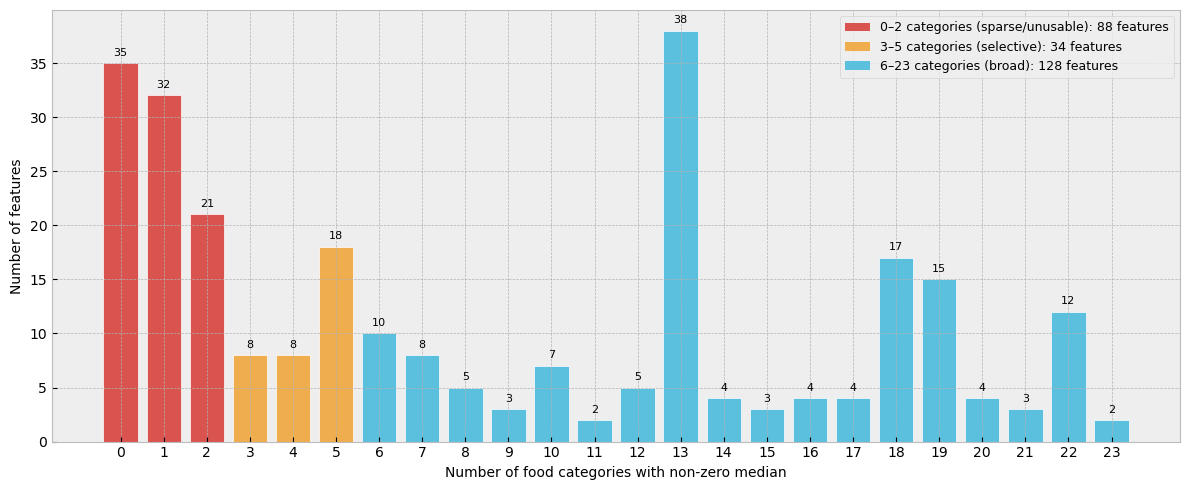

In [82]:
import matplotlib.pyplot as plt
import numpy as np

counts = pd.Series({
    0:35, 1:32, 2:21, 3:8, 4:8, 5:18, 6:10, 7:8, 8:5, 9:3,
    10:7, 11:2, 12:5, 13:38, 14:4, 15:3, 16:4, 17:4, 18:17,
    19:15, 20:4, 21:3, 22:12, 23:2
})

colors = ['#d9534f' if x <= 2 else '#f0ad4e' if x <= 5 else '#5bc0de' 
          for x in counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

# Annotate each bar
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d9534f', label='0–2 categories (sparse/unusable): 88 features'),
    Patch(facecolor='#f0ad4e', label='3–5 categories (selective): 34 features'),
    Patch(facecolor='#5bc0de', label='6–23 categories (broad): 128 features')
]
ax.legend(handles=legend_elements, fontsize=9)

ax.set_xlabel('Number of food categories with non-zero median', fontsize=10)
ax.set_ylabel('Number of features', fontsize=10)
ax.set_xticks(counts.index)
plt.tight_layout()
plt.savefig('feature_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()

In [83]:
# Which features are non-zero in exactly 13 categories?
exactly_13 = nonzero_categories[nonzero_categories == 13].index.tolist()
print(exactly_13[:10])  # first 10

['Serine (mg)', 'Sucrose(g)', 'Threonine (mg)', 'Total dietary fibre (g)', 'Methionine (mg)', 'Phenylalanine (mg)', 'Proline (mg)', 'Tyrosine (mg)', 'Isoleucine (mg)', 'Lysine (mg)']


In [84]:
print(exactly_13)
print(len(exactly_13))

['Serine (mg)', 'Sucrose(g)', 'Threonine (mg)', 'Total dietary fibre (g)', 'Methionine (mg)', 'Phenylalanine (mg)', 'Proline (mg)', 'Tyrosine (mg)', 'Isoleucine (mg)', 'Lysine (mg)', 'Methionine (mg/gN)', 'Proline (mg/gN)', 'Serine (mg/gN)', 'Threonine (mg/gN)', 'Tyrosine (mg/gN)', 'Valine (mg/gN)', 'Lysine (mg/gN)', 'Alanine (mg)', 'Aspartic acid (mg)', 'Cystine plus cysteine (mg)', 'Glutamic acid (mg)', 'Glycine (mg)', 'Histidine (mg)', 'Aluminium (Al) (ug)', 'Arginine (mg)', 'Leucine (mg/gN)', 'Phenylalanine (mg/gN)', 'Histidine (mg/gN)', 'Leucine (mg)', 'Isoleucine (mg/gN)', 'Alanine (mg/gN)', 'Arginine (mg/gN)', 'Aspartic acid (mg/gN)', 'Cystine plus cysteine (mg/gN)', 'C17 (%T)', 'Valine (mg)', 'Glutamic acid (mg/gN)', 'Glycine (mg/gN)']
38


In [85]:
exclusive_nutrients = ['Caffeine (mg)', 'Alcohol (g)', 'Lactose (g)', 'Cholesterol (mg)']

df.groupby('class_2digit')[exclusive_nutrients].median().round(2)

,Caffeine (mg),Alcohol (g),Lactose (g),Cholesterol (mg)
class_2digit,,,,
11,0.0,0.00,0.00,0.0
12,0.0,0.00,0.00,0.0
13,0.0,0.00,0.15,19.0
14,0.0,0.00,0.00,0.0
15,0.0,0.00,0.00,83.0
16,0.0,0.00,0.00,0.0
17,0.0,0.00,0.00,488.0
18,0.0,0.00,0.00,71.0
19,0.0,0.00,3.70,30.0


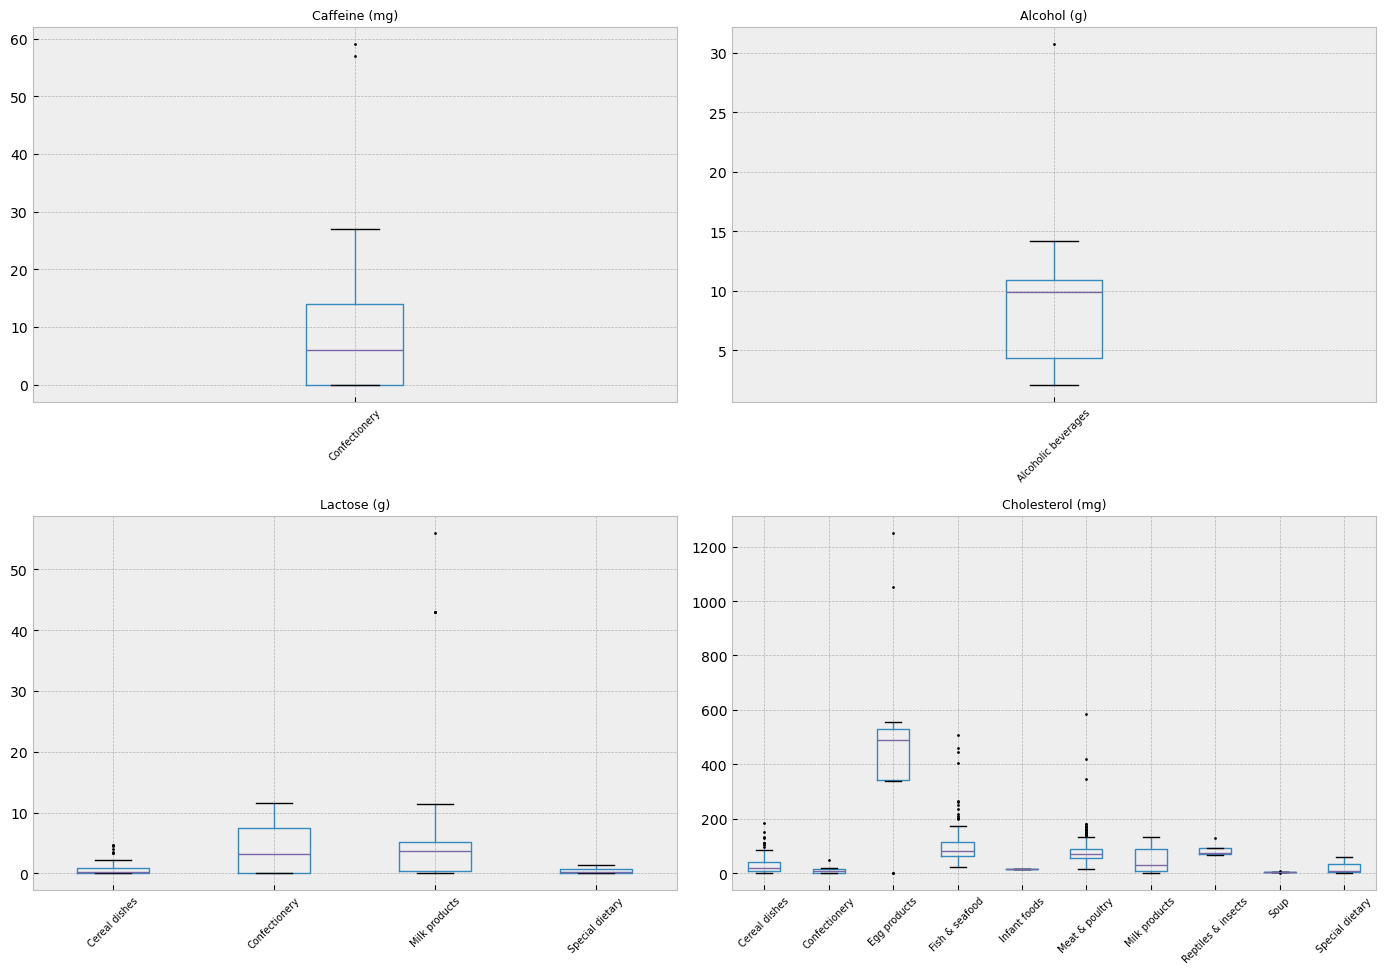

In [91]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
nutrients = ['Caffeine (mg)', 'Alcohol (g)', 'Lactose (g)', 'Cholesterol (mg)']
labels = {v: k for k, v in {
    11: 'Non-alc beverages', 12: 'Cereals', 13: 'Cereal dishes',
    14: 'Fats & oils', 15: 'Fish & seafood', 16: 'Fruit products',
    17: 'Egg products', 18: 'Meat & poultry', 19: 'Milk products',
    20: 'Dairy substitutes', 21: 'Soup', 22: 'Seed & nut',
    23: 'Sauces', 24: 'Vegetable', 25: 'Legumes',
    26: 'Snack foods', 27: 'Sugar products', 28: 'Confectionery',
    29: 'Alcoholic beverages', 30: 'Special dietary', 31: 'Miscellaneous',
    32: 'Infant foods', 33: 'Reptiles & insects'
}.items()}

for ax, nutrient in zip(axes.flatten(), nutrients):
    plot_df = df[['class_2digit', nutrient]].copy()
    plot_df['category'] = plot_df['class_2digit'].map({
        11: 'Non-alc beverages', 12: 'Cereals', 13: 'Cereal dishes',
        14: 'Fats & oils', 15: 'Fish & seafood', 16: 'Fruit products',
        17: 'Egg products', 18: 'Meat & poultry', 19: 'Milk products',
        20: 'Dairy substitutes', 21: 'Soup', 22: 'Seed & nut',
        23: 'Sauces', 24: 'Vegetable', 25: 'Legumes',
        26: 'Snack foods', 27: 'Sugar products', 28: 'Confectionery',
        29: 'Alcoholic beverages', 30: 'Special dietary', 31: 'Miscellaneous',
        32: 'Infant foods', 33: 'Reptiles & insects'
    })
    # Only show categories with non-zero median to keep plot readable
    nonzero_cats = plot_df.groupby('category')[nutrient].median()
    nonzero_cats = nonzero_cats[nonzero_cats > 0].index
    plot_df = plot_df[plot_df['category'].isin(nonzero_cats)]

    plot_df.boxplot(column=nutrient, by='category', ax=ax,
                    flierprops=dict(marker='.', markersize=2))
    ax.set_title(nutrient, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=45)

fig.suptitle('')
plt.tight_layout()
plt.savefig('nutrient_exclusivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Balancing

In [92]:
# Flag problematic columns automatically
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'class_2digit']
for col in numeric_cols:
    skew = df[col].skew()
    null_pct = df[col].isnull().sum() / len(df) * 100
    nunique = df[col].nunique()

    if skew > 2:
        print(f"⚠️  {col} — high skew: {skew:.2f} → consider log transform")
    if null_pct > 30:
        print(f"⚠️  {col} — {null_pct:.1f}% nulls → consider dropping")
    if nunique == 1:
        print(f"❌  {col} — constant column, no variance → drop it")

⚠️  Fat, total (g) — high skew: 3.08 → consider log transform
⚠️  Ash (g) — high skew: 14.50 → consider log transform
⚠️  Total dietary fibre (g) — high skew: 5.46 → consider log transform
⚠️  Alcohol (g) — high skew: 12.61 → consider log transform
⚠️  Fructose (g) — high skew: 6.03 → consider log transform
⚠️  Glucose (g) — high skew: 5.68 → consider log transform
⚠️  Sucrose(g) — high skew: 5.40 → consider log transform
⚠️  Maltose (g) — high skew: 8.14 → consider log transform
⚠️  Lactose (g) — high skew: 13.12 → consider log transform
⚠️  Galactose (g) — high skew: 5.78 → consider log transform
⚠️  Galactose (g) — 90.1% nulls → consider dropping
⚠️  Total sugars (g) — high skew: 3.49 → consider log transform
⚠️  Added sugars (g) — high skew: 4.57 → consider log transform
⚠️  Free sugars (g) — high skew: 4.45 → consider log transform
⚠️  Starch (g) — high skew: 2.04 → consider log transform
⚠️  Dextrin (g) — 99.6% nulls → consider dropping
⚠️  Glycerol (g) — 99.9% nulls → consider d

In [93]:
# Drop constant columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df = df.drop(columns=constant_cols)
print(f"Dropped {len(constant_cols)} constant columns")

Dropped 23 constant columns


In [28]:
# Drop columns with more than 30% nulls
null_threshold = 0.30
null_pct = df.isnull().sum() / len(df)
high_null_cols = null_pct[null_pct > null_threshold].index.tolist()

df = df.drop(columns=high_null_cols)
print(f"Dropped {len(high_null_cols)} high-null columns")

Dropped 165 high-null columns


In [29]:
# Log transform skewed features
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'class_2digit']
skewed_cols = [col for col in numeric_cols if df[col].skew() > 2.0]
for col in skewed_cols:
    df[col] = np.log1p(df[col])
print(f"Log transformed {len(skewed_cols)} skewed columns")

Log transformed 66 skewed columns


## EM Imputation

In [30]:
# EM Imputation on log-transformed data
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0].index.tolist()
print(f"Imputing {len(null_cols)} columns")

imputer = IterativeImputer(
    max_iter=10,  # actual EM iteration
    random_state=42,
    initial_strategy='median'
)

imputed_array = imputer.fit_transform(df[numeric_cols])
df_imputed = pd.DataFrame(imputed_array, columns=numeric_cols, index=df.index)
df[null_cols] = df_imputed[null_cols]

Imputing 20 columns


/opt/miniconda3/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [31]:
# Clip negatives
for col in null_cols:
    if df[col].min() < 0:
        print(f"⚠️  Clipping negative values in {col}")
        df[col] = df[col].clip(lower=0)

print(f"Final nulls: {df.isnull().sum().sum()}")

⚠️  Clipping negative values in Fructose (g)
⚠️  Clipping negative values in Glucose (g)
⚠️  Clipping negative values in Sucrose(g)
⚠️  Clipping negative values in Maltose (g)
⚠️  Clipping negative values in Lactose (g)
⚠️  Clipping negative values in Copper (Cu) (mg)
⚠️  Clipping negative values in Manganese (Mn) (mg)
⚠️  Clipping negative values in Total saturated fatty acids, equated (%T)
⚠️  Clipping negative values in Total monounsaturated fatty acids, equated (%T)
⚠️  Clipping negative values in C18:2w6 (%T)
⚠️  Clipping negative values in C18:3w3 (%T)
⚠️  Clipping negative values in C20:5w3 (%T)
⚠️  Clipping negative values in C22:5w3 (%T)
⚠️  Clipping negative values in C22:6w3 (%T)
⚠️  Clipping negative values in Total polyunsaturated fatty acids, equated (%T)
⚠️  Clipping negative values in Total long chain omega 3 fatty acids, equated (%T)
⚠️  Clipping negative values in Total trans fatty acids, imputed (%T)
⚠️  Clipping negative values in C16 (g)
⚠️  Clipping negative value

## Heatmap

In [32]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'class_2digit']

print(f"Remaining features: {len(numeric_cols)}")
print(numeric_cols)

Remaining features: 80
['Energy with dietary fibre, equated (kJ)', 'Energy, without dietary fibre, equated (kJ)', 'Moisture (water) (g)', 'Protein (g)', 'Nitrogen (g)', 'Fat, total (g)', 'Ash (g)', 'Total dietary fibre (g)', 'Alcohol (g)', 'Fructose (g)', 'Glucose (g)', 'Sucrose(g)', 'Maltose (g)', 'Lactose (g)', 'Total sugars (g)', 'Added sugars (g)', 'Free sugars (g)', 'Starch (g)', 'Available carbohydrate, without sugar alcohols (g)', 'Available carbohydrate, with sugar alcohols (g)', 'Calcium (Ca) (mg)', 'Copper (Cu) (mg)', 'Iodine (I) (ug)', 'Iron (Fe) (mg)', 'Magnesium (Mg) (mg)', 'Manganese (Mn) (mg)', 'Phosphorus (P) (mg)', 'Potassium (K) (mg)', 'Selenium (Se) (ug)', 'Sodium (Na) (mg)', 'Zinc (Zn) (mg)', 'Retinol (preformed vitamin A) (ug)', 'Beta-carotene (ug)', 'Beta-carotene equivalents (provitamin A) (ug)', 'Vitamin A retinol equivalents (ug)', 'Thiamin (B1) (mg)', 'Riboflavin (B2) (mg)', 'Niacin (B3) (mg)', 'Niacin derived from tryptophan (mg)', 'Niacin derived equivalents

In [33]:
feature_groups = {
    'Energy & Macronutrients': [
        'Energy with dietary fibre, equated (kJ)',
        'Energy, without dietary fibre, equated (kJ)',
        'Moisture (water) (g)', 'Protein (g)', 'Nitrogen (g)',
        'Fat, total (g)', 'Ash (g)', 'Total dietary fibre (g)', 'Alcohol (g)'
    ],
    'Carbohydrates & Sugars': [
        'Fructose (g)', 'Glucose (g)', 'Sucrose(g)', 'Maltose (g)',
        'Lactose (g)', 'Total sugars (g)', 'Added sugars (g)',
        'Free sugars (g)', 'Starch (g)',
        'Available carbohydrate, without sugar alcohols (g)',
        'Available carbohydrate, with sugar alcohols (g)'
    ],
    'Minerals': [
        'Calcium (Ca) (mg)', 'Copper (Cu) (mg)', 'Iodine (I) (ug)',
        'Iron (Fe) (mg)', 'Magnesium (Mg) (mg)', 'Manganese (Mn) (mg)',
        'Phosphorus (P) (mg)', 'Potassium (K) (mg)', 'Selenium (Se) (ug)',
        'Sodium (Na) (mg)', 'Zinc (Zn) (mg)'
    ],
    'Vitamins': [
        'Retinol (preformed vitamin A) (ug)', 'Beta-carotene (ug)',
        'Beta-carotene equivalents (provitamin A) (ug)',
        'Vitamin A retinol equivalents (ug)', 'Thiamin (B1) (mg)',
        'Riboflavin (B2) (mg)', 'Niacin (B3) (mg)',
        'Niacin derived from tryptophan (mg)', 'Niacin derived equivalents (mg)',
        'Pyridoxine (B6) (mg)', 'Cobalamin (B12) (ug)', 'Folate, natural (ug)',
        'Folic acid (ug)', 'Total folates (ug)', 'Dietary folate equivalents (ug)',
        'Vitamin C (mg)', 'Cholecalciferol (D3) (ug)', 'Ergocalciferol (D2) (ug)',
        '25-hydroxy cholecalciferol (25-OH D3) (ug)',
        '25-hydroxy ergocalciferol (25-OH D2) (ug)',
        'Vitamin D3 equivalents (ug)', 'Alpha tocopherol (mg)', 'Vitamin E (mg)'
    ],
    'Fatty Acids (%T)': [
        'Total saturated fatty acids, equated (%T)',
        'Total monounsaturated fatty acids, equated (%T)',
        'C18:2w6 (%T)', 'C18:3w3 (%T)', 'C20:5w3 (%T)',
        'C22:5w3 (%T)', 'C22:6w3 (%T)',
        'Total polyunsaturated fatty acids, equated (%T)',
        'Total long chain omega 3 fatty acids, equated (%T)',
        'Total trans fatty acids, imputed (%T)'
    ],
    'Fatty Acids (g/mg)': [
        'C16 (g)', 'Total saturated fatty acids, equated (g)', 'C18:1 (g)',
        'Total monounsaturated fatty acids, equated (g)', 'C18:2w6 (g)',
        'C18:3w3 (g)', 'C20:5w3 (mg)', 'C22:5w3 (mg)', 'C22:6w3 (mg)',
        'Total polyunsaturated fatty acids, equated (g)',
        'Total long chain omega 3 fatty acids, equated (mg)',
        'Total trans fatty acids, imputed (mg)'
    ],
    'Other': [
        'Caffeine (mg)', 'Cholesterol (mg)',
        'Tryptophan (mg/gN)', 'Tryptophan (mg)'
    ]
}

# Verify all features are accounted for
all_grouped = [f for group in feature_groups.values() for f in group]
missing = [f for f in numeric_cols if f not in all_grouped]
extra = [f for f in all_grouped if f not in numeric_cols]

print(f"Missing from groups: {missing}")
print(f"Extra in groups: {extra}")

Missing from groups: []
Extra in groups: []


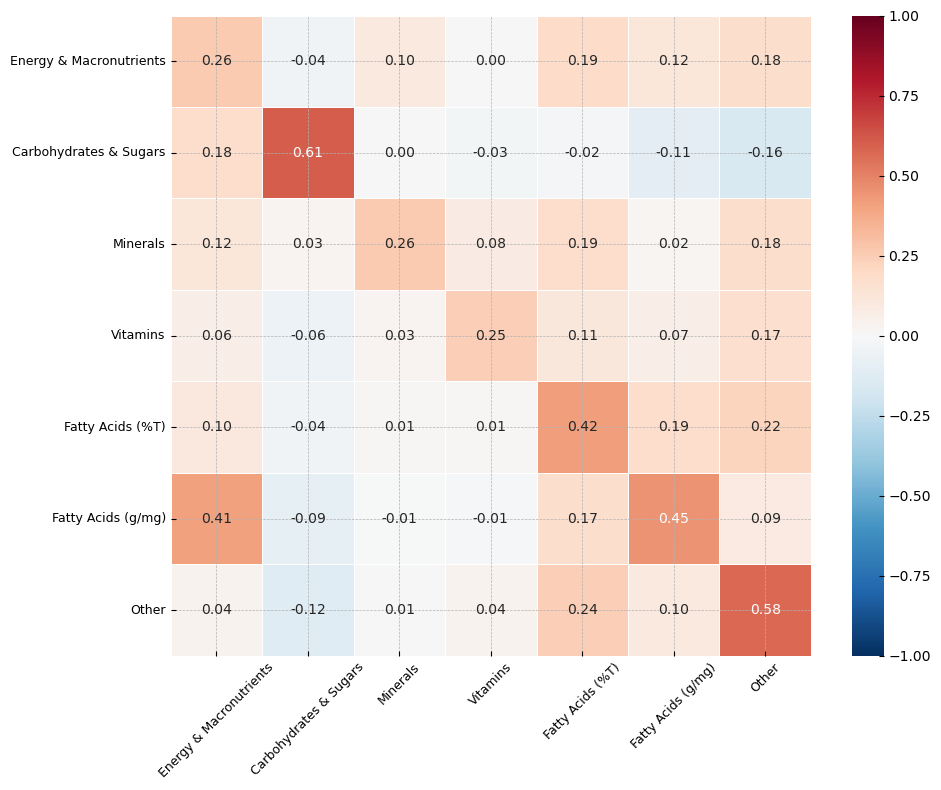

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Compute mean correlation between groups
group_names = list(feature_groups.keys())
n_groups = len(group_names)
group_corr = pd.DataFrame(np.zeros((n_groups, n_groups)), 
                           index=group_names, columns=group_names)

for g1 in group_names:
    for g2 in group_names:
        cols1 = feature_groups[g1]
        cols2 = feature_groups[g2]
        corr_block = df[cols1].corrwith(df[cols2].mean(axis=1))
        group_corr.loc[g1, g2] = corr_block.mean()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    group_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('group_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Class Distribution

class_2digit
18    354
24    249
12    162
16    143
15    115
13    112
11     56
19     56
22     40
23     39
14     38
28     35
31     34
20     34
29     28
25     27
27     22
26     12
17     11
21      6
33      4
30      3
32      1
Name: count, dtype: int64

Class proportions:
class_2digit
18    22.390892
24    15.749526
12    10.246679
16     9.044908
15     7.273877
13     7.084124
11     3.542062
19     3.542062
22     2.530044
23     2.466793
14     2.403542
28     2.213789
31     2.150538
20     2.150538
29     1.771031
25     1.707780
27     1.391524
26     0.759013
17     0.695762
21     0.379507
33     0.253004
30     0.189753
32     0.063251
Name: proportion, dtype: float64


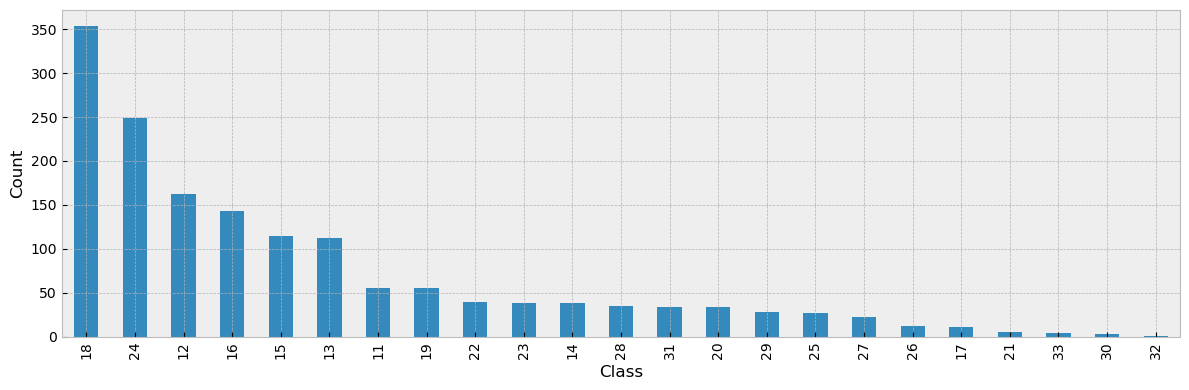

In [95]:
import matplotlib.pyplot as plt

print(df['class_2digit'].value_counts())
print(f"\nClass proportions:\n{df['class_2digit'].value_counts(normalize=True) * 100}")

df['class_2digit'].value_counts().plot(kind='bar', figsize=(12, 4))
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [38]:
min_samples = 15
valid_classes = df['class_2digit'].value_counts()
valid_classes = valid_classes[valid_classes >= min_samples].index
df = df[df['class_2digit'].isin(valid_classes)]

class_2digit
18    354
24    249
12    162
16    143
15    115
13    112
11     56
19     56
22     40
23     39
14     38
28     35
31     34
20     34
29     28
25     27
27     22
Name: count, dtype: int64

Class proportions:
class_2digit
18    22.927461
24    16.126943
12    10.492228
16     9.261658
15     7.448187
13     7.253886
11     3.626943
19     3.626943
22     2.590674
23     2.525907
14     2.461140
28     2.266839
31     2.202073
20     2.202073
29     1.813472
25     1.748705
27     1.424870
Name: proportion, dtype: float64


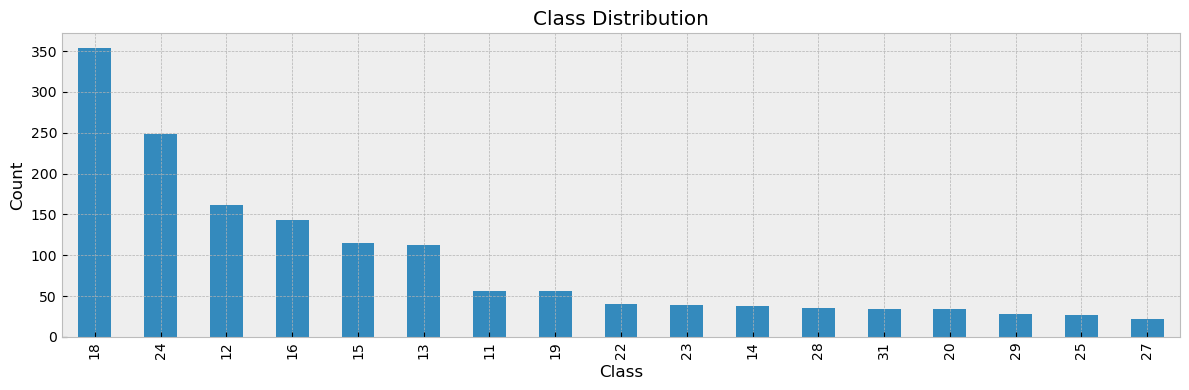

In [39]:
import matplotlib.pyplot as plt

print(df['class_2digit'].value_counts())
print(f"\nClass proportions:\n{df['class_2digit'].value_counts(normalize=True) * 100}")

df['class_2digit'].value_counts().plot(kind='bar', figsize=(12, 4))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Split

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.pipeline import Pipeline
import numpy as np
import pandas as pd

X = df.drop(columns=['class_2digit'])
y = df['class_2digit']

# ─────────────────────────────────────────
# Step 1: Split first
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

# ─────────────────────────────────────────
# Step 2: Resample train only
# ─────────────────────────────────────────
resample_pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy={
        cls: 50 for cls, count in y_train.value_counts().items() if count < 50
    }, random_state=42, k_neighbors=5)),
    ('undersample', RandomUnderSampler(sampling_strategy={
        cls: 200 for cls, count in y_train.value_counts().items() if count > 200
    }, random_state=42)),
    ('tomek', TomekLinks())
])

X_train_res, y_train_res = resample_pipeline.fit_resample(X_train, y_train)

print(f"\nClass distribution after resampling:")
print(pd.Series(y_train_res).value_counts().sort_index())

# ─────────────────────────────────────────
# Step 3: Scale after resampling
# ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)  # fit on train only
X_test_scaled  = scaler.transform(X_test)           # same scaler on test

print(f"\nFinal shapes:")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"y_train_res:    {y_train_res.shape}")
print(f"y_test:         {y_test.shape}")

# ─────────────────────────────────────────
# Step 4: Stratified K-Fold ready to use
# ─────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nStratified K-Fold configured — 5 folds")
print(f"Ready for modelling — plug in your model when ready")

# When ready, plug in like this:
# ─────────────────────────────────────────
# from sklearn.XXX import YourModel
# model = YourModel(class_weight='balanced')
# 
# cv_scores = cross_val_score(
#     model,
#     X_train_scaled, y_train_res,
#     cv=skf,
#     scoring='balanced_accuracy',
#     n_jobs=-1
# )
# print(f"CV Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
#
# model.fit(X_train_scaled, y_train_res)
# y_pred = model.predict(X_test_scaled)

Train size: (1235, 80)
Test size:  (309, 80)

Class distribution after resampling:
class_2digit
11     50
12    112
13     74
14     47
15     78
16    101
18    182
19     44
20     46
22     46
23     41
24    185
25     45
27     48
28     44
29     48
31     48
Name: count, dtype: int64

Final shapes:
X_train_scaled: (1239, 80)
X_test_scaled:  (309, 80)
y_train_res:    (1239,)
y_test:         (309,)

Stratified K-Fold configured — 5 folds
Ready for modelling — plug in your model when ready


# Logistic Regression

In [45]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000],
    'class_weight': ['balanced'],
    'penalty': ['l2']
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=lr_param_grid,
    n_iter=12,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lr_search.fit(X_train_scaled, y_train_res)

print(f"Best params: {lr_search.best_params_}")
print(f"Best CV score: {lr_search.best_score_:.3f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'pen

Best params: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 1000, 'class_weight': 'balanced', 'C': 1}
Best CV score: 0.931


Stratified K-Fold CV Results (5 folds):
  Per fold:  ['0.961', '0.913', '0.933', '0.906', '0.930']
  Mean:      0.929
  Std:       0.019
  95% CI:    0.890 – 0.967

Classification Report:
              precision    recall  f1-score   support

          11       0.77      0.91      0.83        11
          12       0.91      0.91      0.91        32
          13       0.83      0.91      0.87        22
          14       1.00      1.00      1.00         8
          15       1.00      1.00      1.00        23
          16       0.89      0.86      0.88        29
          18       1.00      0.99      0.99        71
          19       0.91      0.91      0.91        11
          20       0.86      0.86      0.86         7
          22       0.86      0.75      0.80         8
          23       0.78      0.88      0.82         8
          24       0.92      0.92      0.92        50
          25       1.00      0.60      0.75         5
          27       0.33      0.25      0.29         4
 

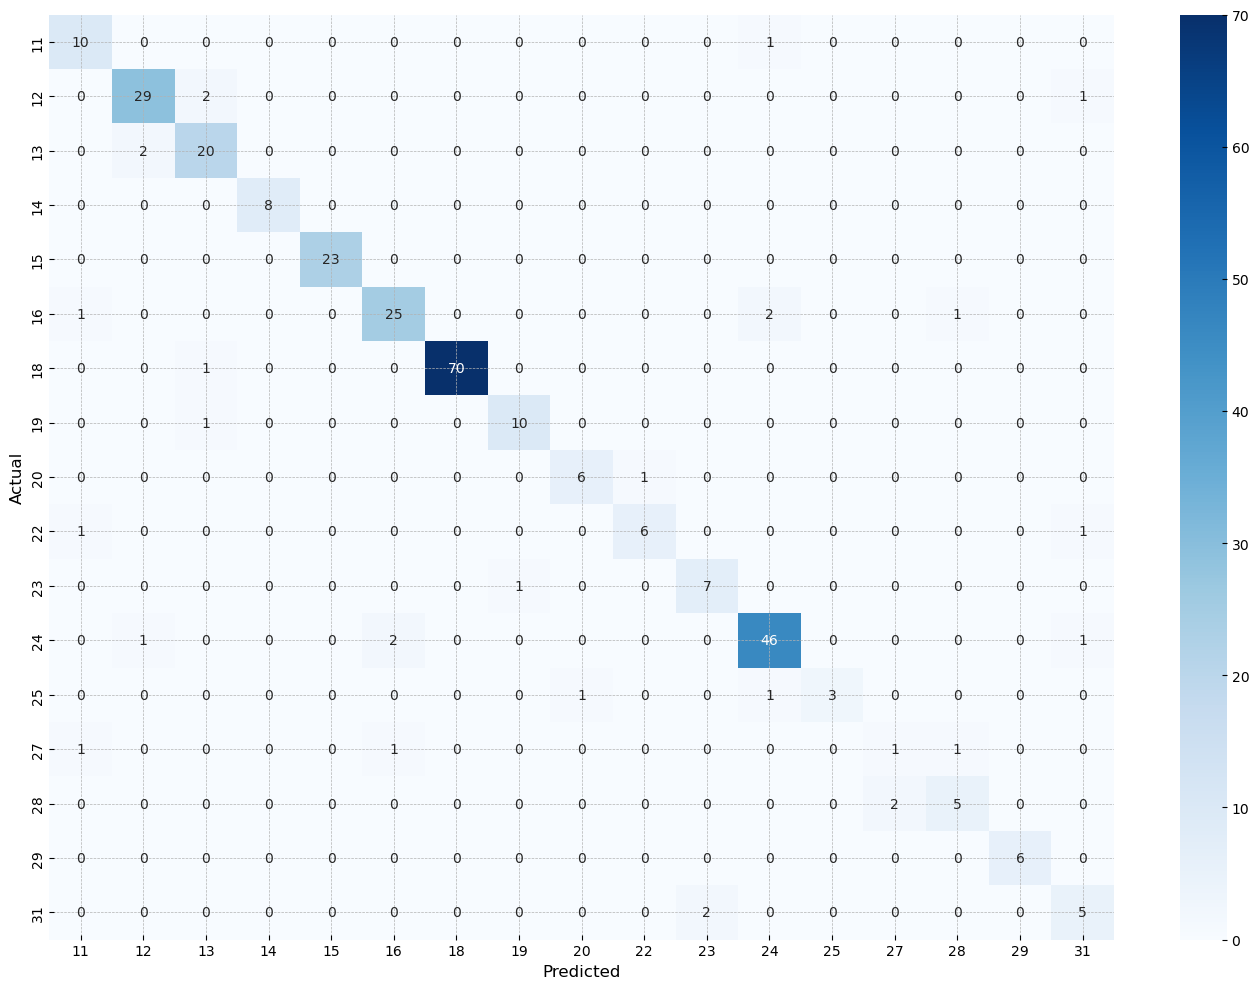

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# Step 1: Define model
# ─────────────────────────────────────────
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# ─────────────────────────────────────────
# Step 2: Cross validation
# ─────────────────────────────────────────
cv_scores = cross_val_score(
    model,
    X_train_scaled, y_train_res,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1
)

print(f"Stratified K-Fold CV Results (5 folds):")
print(f"  Per fold:  {[f'{s:.3f}' for s in cv_scores]}")
print(f"  Mean:      {cv_scores.mean():.3f}")
print(f"  Std:       {cv_scores.std():.3f}")
print(f"  95% CI:    {cv_scores.mean() - 2*cv_scores.std():.3f} "
      f"– {cv_scores.mean() + 2*cv_scores.std():.3f}")

# ─────────────────────────────────────────
# Step 3: Final fit on full training data
# ─────────────────────────────────────────
model.fit(X_train_scaled, y_train_res)

# ─────────────────────────────────────────
# Step 4: Evaluate on test set
# ─────────────────────────────────────────
y_pred = model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ─────────────────────────────────────────
# Step 5: Confusion matrix
# ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_lr.png", dpi=150)
plt.show()

# Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train_scaled, y_train_res)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV score: {rf_search.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `skle

Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced'}
Best CV score: 0.917


Stratified K-Fold CV Results (5 folds):
  Per fold:  ['0.932', '0.895', '0.908', '0.913', '0.935']
  Mean:      0.917
  Std:       0.015
  95% CI:    0.887 – 0.946

Classification Report:
              precision    recall  f1-score   support

          11       0.82      0.82      0.82        11
          12       0.91      0.91      0.91        32
          13       0.88      0.95      0.91        22
          14       1.00      1.00      1.00         8
          15       0.96      1.00      0.98        23
          16       0.90      0.93      0.92        29
          18       1.00      0.99      0.99        71
          19       0.91      0.91      0.91        11
          20       0.86      0.86      0.86         7
          22       0.78      0.88      0.82         8
          23       0.83      0.62      0.71         8
          24       0.96      0.98      0.97        50
          25       1.00      0.80      0.89         5
          27       0.33      0.50      0.40         4
 

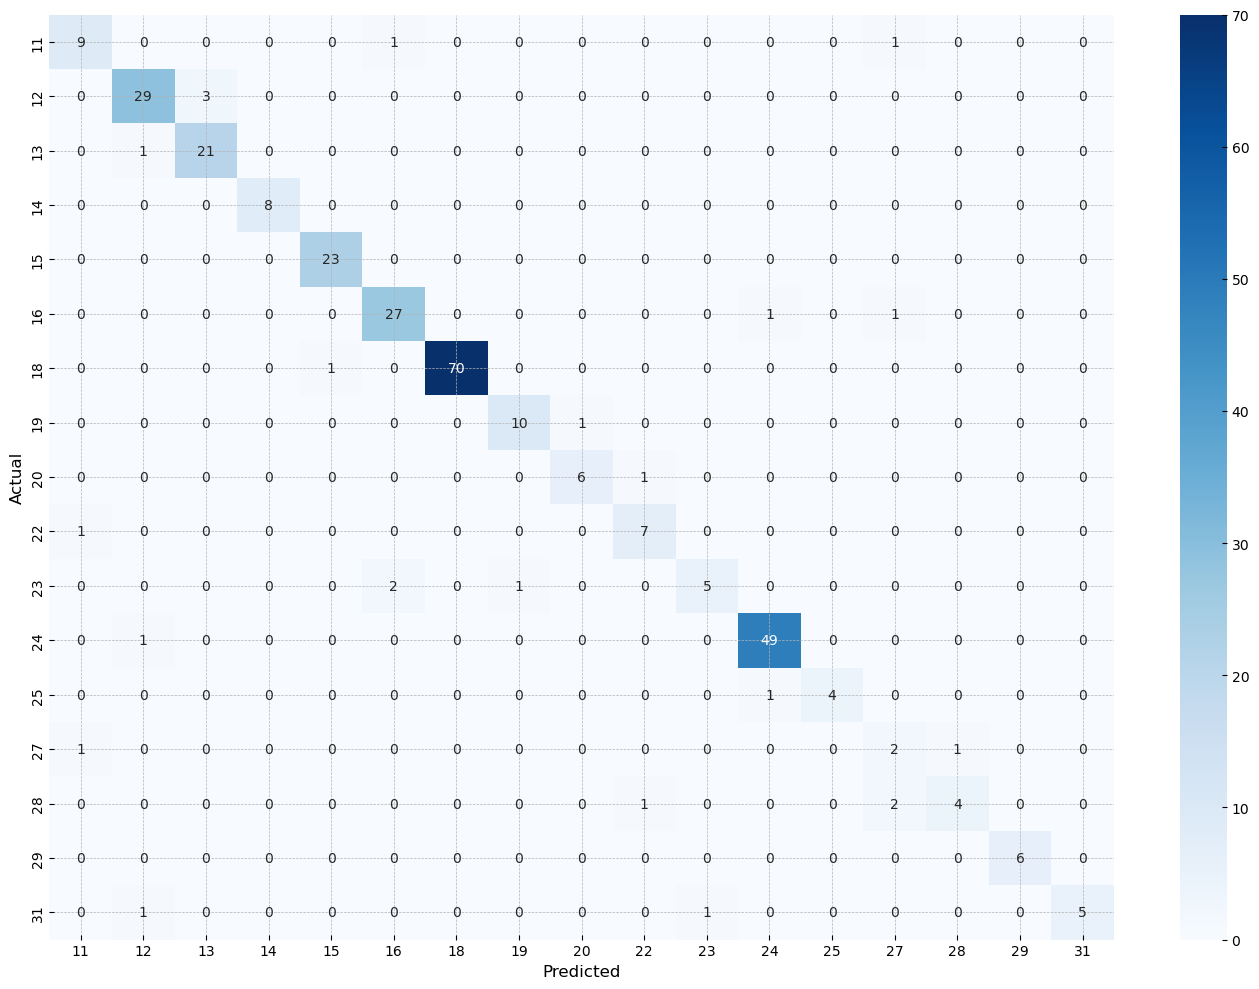


Computing proximity matrix...
Proximity matrix shape: (309, 309)


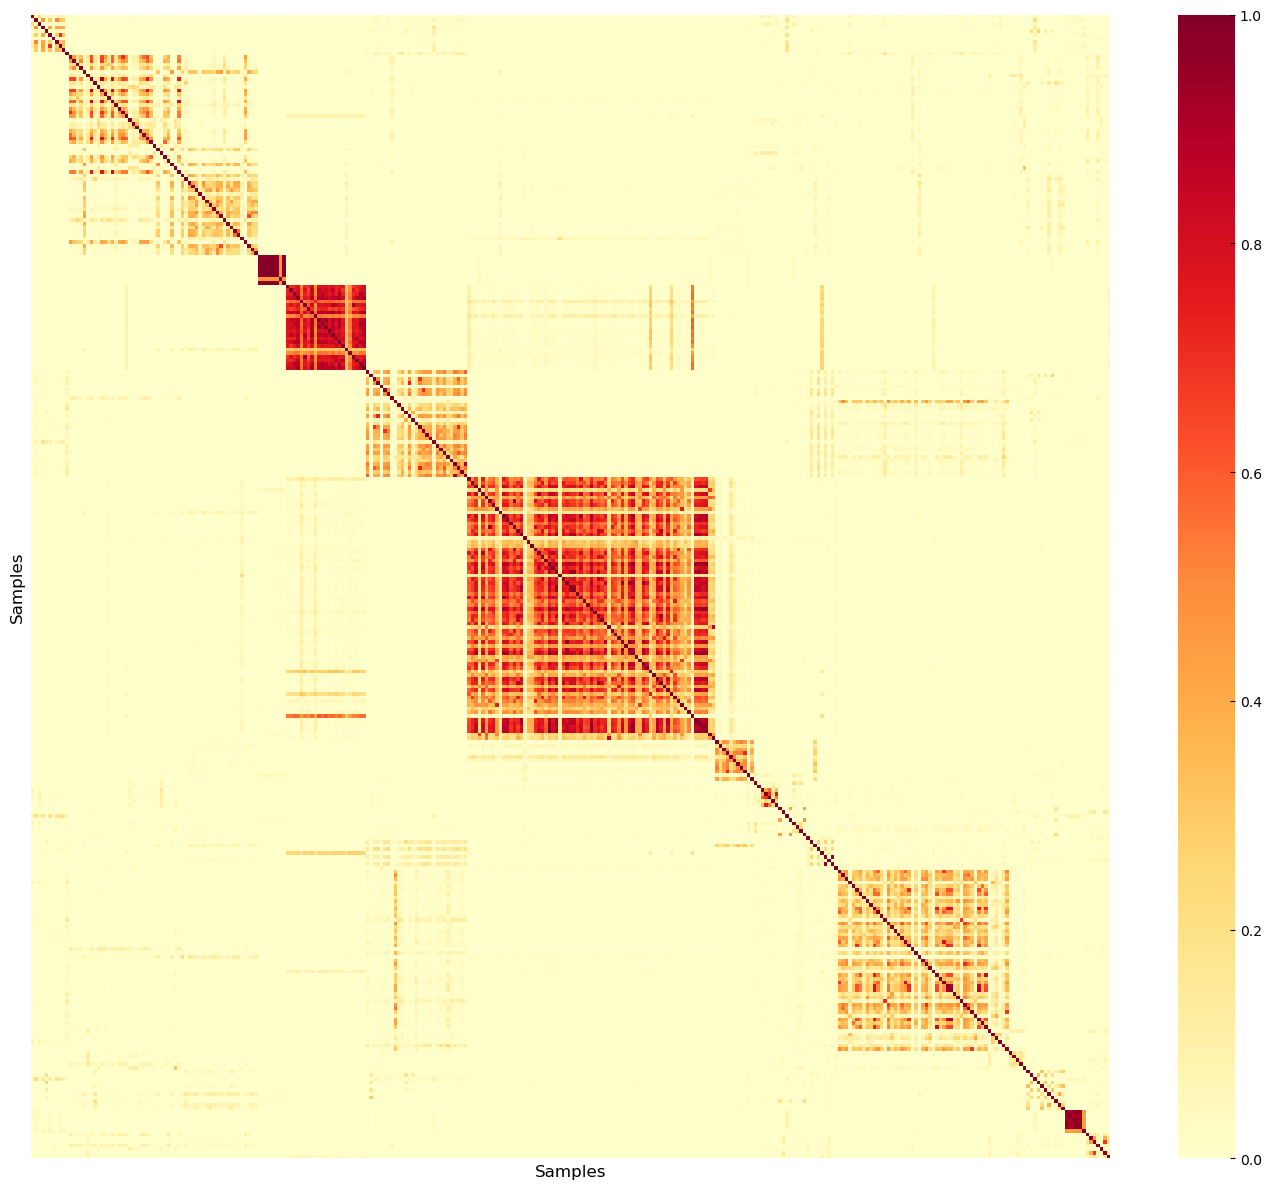


Proximity-based outliers in test set: 0

Top 20 Most Important Features:
                                           feature  importance
Available carbohydrate, without sugar alcohols (g)    0.027679
                                       Alcohol (g)    0.027620
           Energy with dietary fibre, equated (kJ)    0.026879
                              Moisture (water) (g)    0.026269
   Available carbohydrate, with sugar alcohols (g)    0.026158
       Energy, without dietary fibre, equated (kJ)    0.024977
                           Total dietary fibre (g)    0.024765
                                        Starch (g)    0.023915
                                    Fat, total (g)    0.022661
                               Phosphorus (P) (mg)    0.022046
                                  Total sugars (g)    0.021749
                                           Ash (g)    0.021180
                                  Cholesterol (mg)    0.020438
                                Potassium (K

<Figure size 1000x800 with 0 Axes>

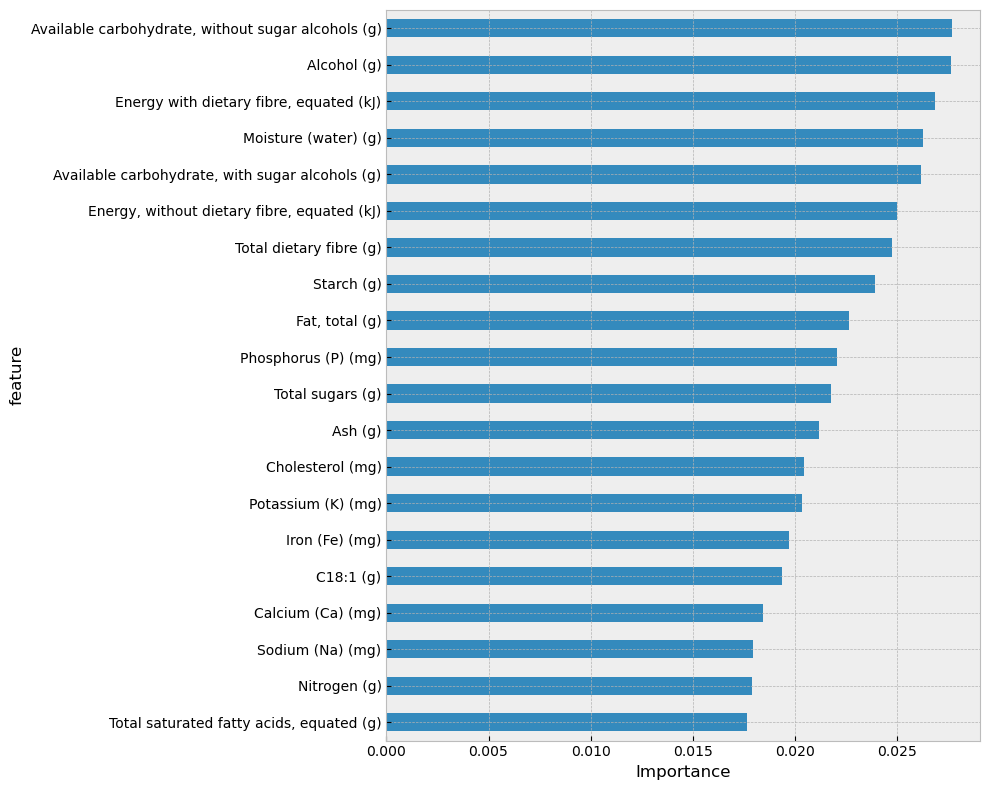

In [97]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# Step 1: Define model
# ─────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# ─────────────────────────────────────────
# Step 2: Cross validation
# ─────────────────────────────────────────
cv_scores = cross_val_score(
    rf_model,
    X_train_scaled, y_train_res,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1
)

print(f"Stratified K-Fold CV Results (5 folds):")
print(f"  Per fold:  {[f'{s:.3f}' for s in cv_scores]}")
print(f"  Mean:      {cv_scores.mean():.3f}")
print(f"  Std:       {cv_scores.std():.3f}")
print(f"  95% CI:    {cv_scores.mean() - 2*cv_scores.std():.3f} "
      f"– {cv_scores.mean() + 2*cv_scores.std():.3f}")

# ─────────────────────────────────────────
# Step 3: Final fit on full training data
# ─────────────────────────────────────────
rf_model.fit(X_train_scaled, y_train_res)

# ─────────────────────────────────────────
# Step 4: Evaluate on test set
# ─────────────────────────────────────────
y_pred = rf_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ─────────────────────────────────────────
# Step 5: Confusion matrix
# ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150)
plt.show()

# ─────────────────────────────────────────
# Step 6: Proximity Matrix
# ─────────────────────────────────────────
print("\nComputing proximity matrix...")

def compute_proximity(model, X):
    """
    Proximity = how often two samples end up
    in the same leaf node across all trees
    """
    n_samples = X.shape[0]
    proximity = np.zeros((n_samples, n_samples))

    for tree in model.estimators_:
        # Get leaf node ID for each sample
        leaf_ids = tree.apply(X)
        # Increment proximity if two samples share a leaf
        for i in range(n_samples):
            proximity[i] += (leaf_ids == leaf_ids[i])

    # Normalise by number of trees
    proximity /= len(model.estimators_)
    return proximity

# Compute on test set (manageable size)
proximity_matrix = compute_proximity(rf_model, X_test_scaled)

print(f"Proximity matrix shape: {proximity_matrix.shape}")

# ─────────────────────────────────────────
# Step 7: Plot proximity heatmap
# sorted by true class for interpretability
# ─────────────────────────────────────────
# Sort test samples by true class
sort_idx = np.argsort(y_test.values)
proximity_sorted = proximity_matrix[sort_idx][:, sort_idx]
y_test_sorted = y_test.values[sort_idx]

plt.figure(figsize=(14, 12))
sns.heatmap(proximity_sorted, cmap='YlOrRd',
            xticklabels=False, yticklabels=False)
plt.xlabel("Samples")
plt.ylabel("Samples")
plt.tight_layout()
plt.savefig("proximity_matrix.png", dpi=150)
plt.show()

# ─────────────────────────────────────────
# Step 8: Proximity-based outlier detection
# Low average proximity = outlier
# ─────────────────────────────────────────
avg_proximity = proximity_matrix.mean(axis=1)
outlier_threshold = avg_proximity.mean() - 2 * avg_proximity.std()

outliers = np.where(avg_proximity < outlier_threshold)[0]
print(f"\nProximity-based outliers in test set: {len(outliers)}")
for idx in outliers:
    print(f"  Sample {idx} — true class: {y_test.values[idx]} "
          f"| predicted: {y_pred[idx]} "
          f"| avg proximity: {avg_proximity[idx]:.3f}")

# ─────────────────────────────────────────
# Step 9: Feature importance
# ─────────────────────────────────────────
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

# Plot top 20
plt.figure(figsize=(10, 8))
feature_importance.head(20).plot(
    kind='barh', x='feature', y='importance',
    legend=False, figsize=(10, 8)
)
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=150)
plt.show()

# Gradient Boosting

In [47]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_param_grid = {
    'max_iter': [300, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 6, 8],
    'min_samples_leaf': [5, 10, 20],
    'l2_regularization': [0.0, 0.1, 1.0],
    'class_weight': ['balanced']
}

gb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

gb_search.fit(X_train_scaled, y_train_res)

print(f"Best params: {gb_search.best_params_}")
print(f"Best CV score: {gb_search.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'min_samples_leaf': 5, 'max_iter': 300, 'max_depth': 3, 'learning_rate': 0.05, 'l2_regularization': 0.1, 'class_weight': 'balanced'}
Best CV score: 0.921


Stratified K-Fold CV Results (5 folds):
  Per fold:  ['0.924', '0.877', '0.938', '0.899', '0.928']
  Mean:      0.913
  Std:       0.022
  95% CI:    0.869 – 0.957

Classification Report:
              precision    recall  f1-score   support

          11       0.75      0.82      0.78        11
          12       0.90      0.88      0.89        32
          13       0.87      0.91      0.89        22
          14       1.00      1.00      1.00         8
          15       0.88      1.00      0.94        23
          16       0.93      0.93      0.93        29
          18       1.00      0.97      0.99        71
          19       0.91      0.91      0.91        11
          20       1.00      0.86      0.92         7
          22       0.78      0.88      0.82         8
          23       1.00      0.75      0.86         8
          24       0.98      0.96      0.97        50
          25       0.80      0.80      0.80         5
          27       0.40      0.50      0.44         4
 

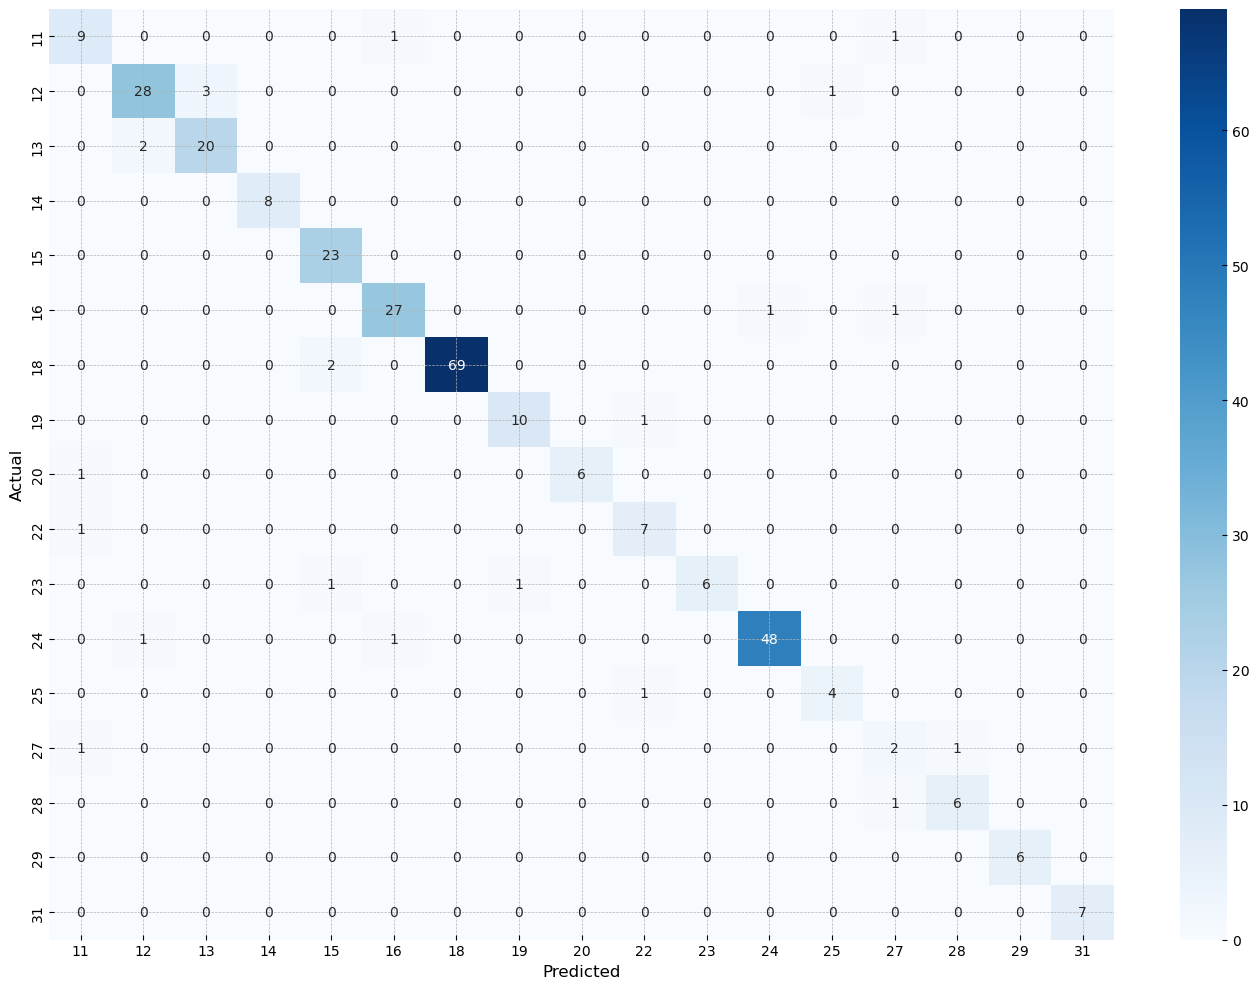

Computing permutation importance (this may take a minute)...

Top 20 Most Important Features:
                                        feature  importance      std
                                     Starch (g)    0.086731 0.007207
                           Moisture (water) (g)    0.046926 0.006979
                               Sodium (Na) (mg)    0.029126 0.009922
                                 Fat, total (g)    0.023625 0.002913
                                 Vitamin C (mg)    0.019741 0.006383
                                   Fructose (g)    0.017476 0.003883
                                Iodine (I) (ug)    0.014887 0.003604
                            Manganese (Mn) (mg)    0.013916 0.004588
                                        Ash (g)    0.013269 0.002688
                                    Alcohol (g)    0.012621 0.001743
                                    Protein (g)    0.009061 0.002422
                              Calcium (Ca) (mg)    0.009061 0.003486
         

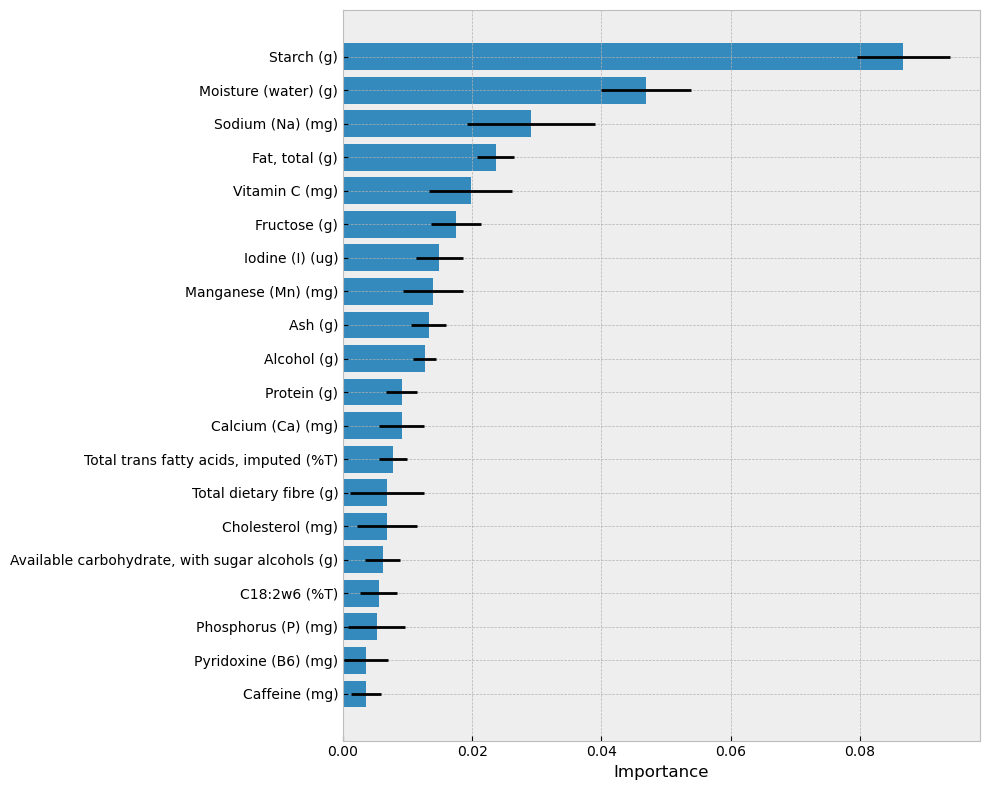


── Model Comparison ──────────────────
Logistic Regression  CV: 0.932 ± 0.015  Test Acc: 0.90  Macro F1: 0.83
Random Forest        CV: 0.917 ± 0.014  Test Acc: 0.91  Macro F1: 0.84
Gradient Boosting    CV: 0.913 ± 0.022  Test Acc: —  Macro F1: —


In [98]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ─────────────────────────────────────────
# Step 1: Define model
# ─────────────────────────────────────────
gb_model = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.05,       # smaller = more robust, slower
    max_depth=6,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

# ─────────────────────────────────────────
# Step 2: Cross validation
# ─────────────────────────────────────────
cv_scores = cross_val_score(
    gb_model,
    X_train_scaled, y_train_res,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1
)

print(f"Stratified K-Fold CV Results (5 folds):")
print(f"  Per fold:  {[f'{s:.3f}' for s in cv_scores]}")
print(f"  Mean:      {cv_scores.mean():.3f}")
print(f"  Std:       {cv_scores.std():.3f}")
print(f"  95% CI:    {cv_scores.mean() - 2*cv_scores.std():.3f} "
      f"– {cv_scores.mean() + 2*cv_scores.std():.3f}")

# ─────────────────────────────────────────
# Step 3: Final fit on full training data
# ─────────────────────────────────────────
gb_model.fit(X_train_scaled, y_train_res)

# ─────────────────────────────────────────
# Step 4: Evaluate on test set
# ─────────────────────────────────────────
y_pred = gb_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ─────────────────────────────────────────
# Step 5: Confusion matrix
# ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_gb.png", dpi=150)
plt.show()

from sklearn.inspection import permutation_importance

# ─────────────────────────────────────────
# Step 6: Feature importance via permutation
# ─────────────────────────────────────────
print("Computing permutation importance (this may take a minute)...")

perm_importance = permutation_importance(
    gb_model,
    X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print(f"\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

# Plot top 20
plt.figure(figsize=(10, 8))
top20 = feature_importance.head(20)
plt.barh(top20['feature'], top20['importance'], xerr=top20['std'])
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance_gb.png", dpi=150)
plt.show()

# ─────────────────────────────────────────
# Step 7: Full model comparison so far
# ─────────────────────────────────────────
print("\n── Model Comparison ──────────────────")
print(f"Logistic Regression  CV: 0.932 ± 0.015  Test Acc: 0.90  Macro F1: 0.83")
print(f"Random Forest        CV: 0.917 ± 0.014  Test Acc: 0.91  Macro F1: 0.84")
print(f"Gradient Boosting    CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}  Test Acc: —  Macro F1: —")

## Concs

In [44]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

# Recompute predictions for all three models
y_pred_lr = model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_gb = gb_model.predict(X_test_scaled)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'CV Mean': [0.929, 0.917, 0.913],
    'CV Std': [0.019, 0.015, 0.022],
    'CV 95% CI Lower': [0.890, 0.887, 0.869],
    'CV 95% CI Upper': [0.967, 0.946, 0.957],
    'Test Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_gb, average='macro')
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred_lr),
        balanced_accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test, y_pred_gb)
    ]
})

print(results.round(3).to_string(index=False))

              Model  CV Mean  CV Std  CV 95% CI Lower  CV 95% CI Upper  Test Accuracy  Macro F1  Balanced Accuracy
Logistic Regression    0.929   0.019            0.890            0.967          0.906     0.836              0.833
      Random Forest    0.917   0.015            0.887            0.946          0.922     0.858              0.849
  Gradient Boosting    0.913   0.022            0.869            0.957          0.926     0.882              0.883


## Tuned Summary

### Optuna

In [49]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─────────────────────────────────────────
# Logistic Regression
# ─────────────────────────────────────────
def lr_objective(trial):
    C = trial.suggest_float('C', 0.001, 100, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])
    
    model = LogisticRegression(
        C=C,
        solver=solver,
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    )
    return cross_val_score(
        model, X_train_scaled, y_train_res,
        cv=skf, scoring='balanced_accuracy', n_jobs=-1
    ).mean()

lr_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
lr_study.optimize(lr_objective, n_trials=50)
print(f"LR Best params: {lr_study.best_params}")
print(f"LR Best CV: {lr_study.best_value:.3f}")

# ─────────────────────────────────────────
# Random Forest
# ─────────────────────────────────────────
def rf_objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2'])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    return cross_val_score(
        model, X_train_scaled, y_train_res,
        cv=skf, scoring='balanced_accuracy', n_jobs=-1
    ).mean()

rf_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=50)
print(f"RF Best params: {rf_study.best_params}")
print(f"RF Best CV: {rf_study.best_value:.3f}")

# ─────────────────────────────────────────
# Gradient Boosting
# ─────────────────────────────────────────
def gb_objective(trial):
    max_iter = trial.suggest_int('max_iter', 100, 1000)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 50)
    l2_regularization = trial.suggest_float('l2_regularization', 0.0, 2.0)

    model = HistGradientBoostingClassifier(
        max_iter=max_iter,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        l2_regularization=l2_regularization,
        class_weight='balanced',
        random_state=42
    )
    return cross_val_score(
        model, X_train_scaled, y_train_res,
        cv=skf, scoring='balanced_accuracy', n_jobs=-1
    ).mean()

gb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
gb_study.optimize(gb_objective, n_trials=50)
print(f"GB Best params: {gb_study.best_params}")
print(f"GB Best CV: {gb_study.best_value:.3f}")

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13

LR Best params: {'C': 1.5301660878899594, 'solver': 'lbfgs'}
LR Best CV: 0.932
RF Best params: {'n_estimators': 278, 'max_depth': 32, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}
RF Best CV: 0.920
GB Best params: {'max_iter': 925, 'learning_rate': 0.23079135592662062, 'max_depth': 2, 'min_samples_leaf': 28, 'l2_regularization': 0.82556542968046}
GB Best CV: 0.929


In [50]:
# Fix LR convergence then refit all three with Optuna params
lr_optuna = LogisticRegression(
    C=1.530, solver='lbfgs',
    max_iter=2000,  # increased to fix convergence
    class_weight='balanced', random_state=42
)

rf_optuna = RandomForestClassifier(
    n_estimators=278, max_depth=32,
    min_samples_split=4, min_samples_leaf=2,
    max_features='log2', class_weight='balanced',
    random_state=42, n_jobs=-1
)

gb_optuna = HistGradientBoostingClassifier(
    max_iter=925, learning_rate=0.231,
    max_depth=2, min_samples_leaf=28,
    l2_regularization=0.826,
    class_weight='balanced', random_state=42
)

# Fit and evaluate
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

for name, m in [('LR', lr_optuna), ('RF', rf_optuna), ('GB', gb_optuna)]:
    m.fit(X_train_scaled, y_train_res)
    y_pred = m.predict(X_test_scaled)
    print(f"{name}: Acc={accuracy_score(y_test, y_pred):.3f} "
          f"F1={f1_score(y_test, y_pred, average='macro'):.3f} "
          f"BalAcc={balanced_accuracy_score(y_test, y_pred):.3f}")

LR: Acc=0.903 F1=0.834 BalAcc=0.832
RF: Acc=0.903 F1=0.829 BalAcc=0.830
GB: Acc=0.919 F1=0.864 BalAcc=0.855


### Random

LR fitted
RF fitted
GB fitted

Tuned Model Comparison:
              Model  CV Mean (tuned)  Test Accuracy  Macro F1  Balanced Accuracy
Logistic Regression            0.931          0.900     0.832              0.831
      Random Forest            0.917          0.916     0.860              0.853
  Gradient Boosting            0.921          0.919     0.878              0.869


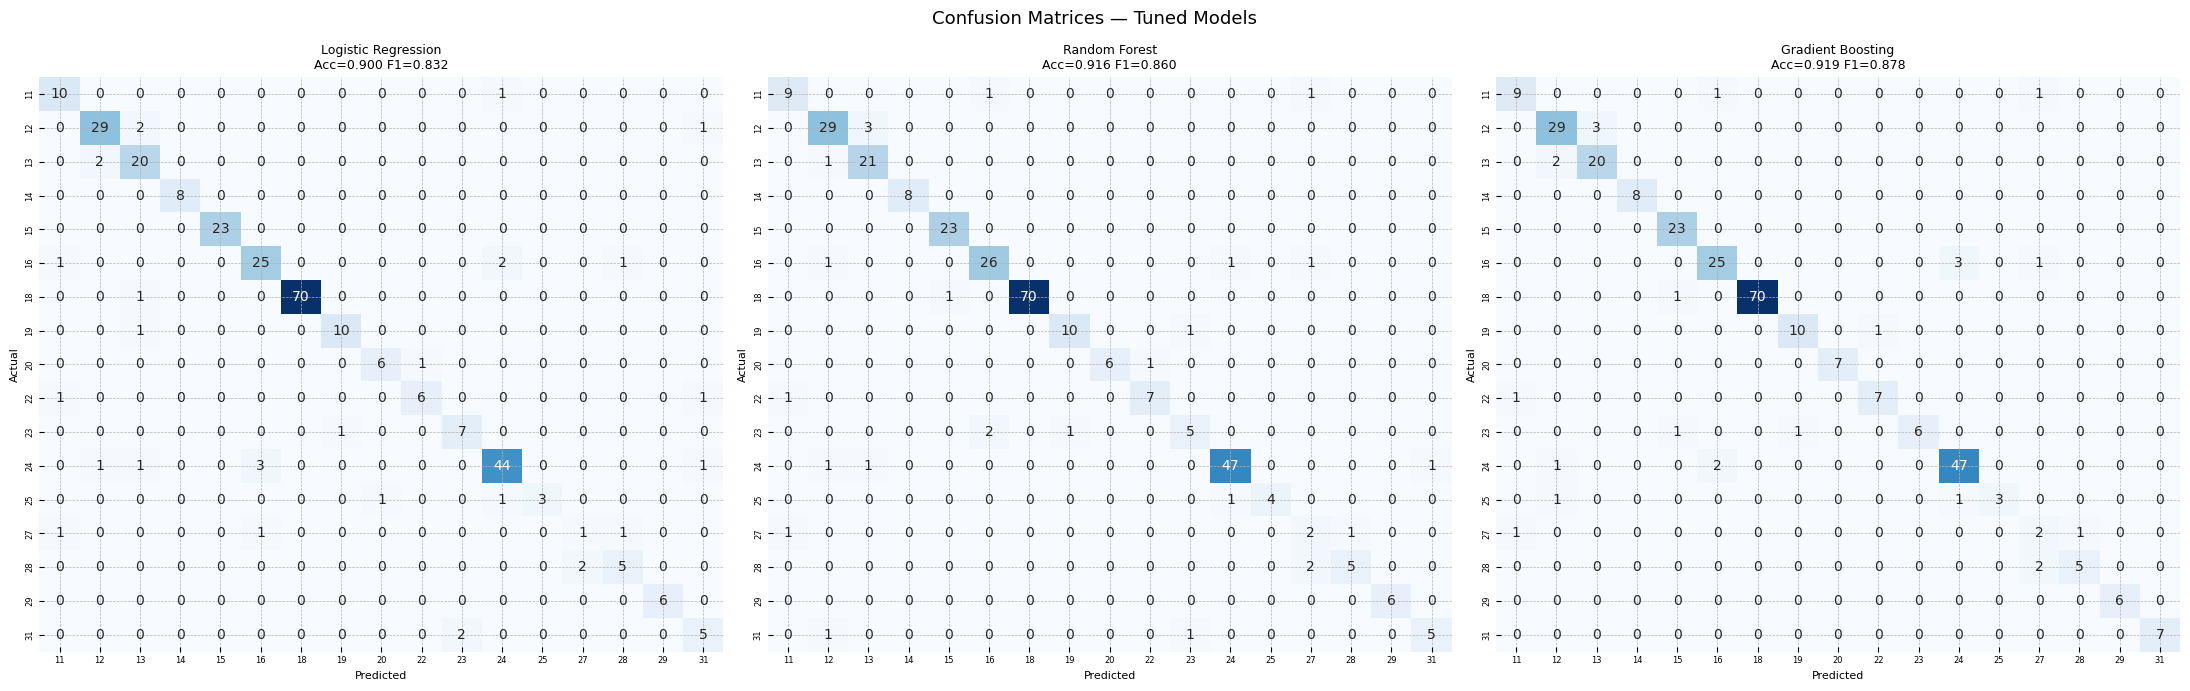

In [48]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ── Tuned models ──────────────────────────────────────────
lr_tuned = LogisticRegression(
    C=1, solver='saga', max_iter=1000,
    class_weight='balanced', random_state=42
)

rf_tuned = RandomForestClassifier(
    n_estimators=500, max_depth=30, max_features='log2',
    min_samples_leaf=1, min_samples_split=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)

gb_tuned = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.05, max_depth=3,
    min_samples_leaf=5, l2_regularization=0.1,
    class_weight='balanced', random_state=42
)

# ── Fit all three ─────────────────────────────────────────
for name, m in [('LR', lr_tuned), ('RF', rf_tuned), ('GB', gb_tuned)]:
    m.fit(X_train_scaled, y_train_res)
    print(f"{name} fitted")

# ── Evaluate ──────────────────────────────────────────────
models = {
    'Logistic Regression': lr_tuned,
    'Random Forest': rf_tuned,
    'Gradient Boosting': gb_tuned
}

results = []
for name, m in models.items():
    y_pred = m.predict(X_test_scaled)
    results.append({
        'Model': name,
        'CV Mean (tuned)': {
            'Logistic Regression': 0.931,
            'Random Forest': 0.917,
            'Gradient Boosting': 0.921
        }[name],
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print("\nTuned Model Comparison:")
print(results_df.round(3).to_string(index=False))

# ── Confusion matrices ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, (name, m) in zip(axes, models.items()):
    y_pred = m.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y.unique()),
                yticklabels=sorted(y.unique()),
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nAcc={accuracy_score(y_test, y_pred):.3f} F1={f1_score(y_test, y_pred, average='macro'):.3f}",
                 fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(labelsize=6)

plt.suptitle("Confusion Matrices — Tuned Models", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrices_tuned.png", dpi=150, bbox_inches='tight')
plt.show()